(chap-exploring_a_database)=
# Exploring a database with `csv`


```{important}
Usually, directories of experimental records are produced by colleagues in the lab. It is essential that there is ongoing discussion between the experimentalists and the people who will later analyze the data, such as data scientists. If data scientists modify the structure of the records directory, it becomes much harder to maintain this communication and can significantly slow down the process of data exploitation and analysis. Therefore, following good practices for organizing and managing the data is crucial.
```

We consider a dataset in `data/records_fake`.  

This dataset consists of a set of (empty) records compiled in 2024, from March 15 to June 26, by [Joanna Danielewicz](https://www.linkedin.com/in/joanna-danielewicz-522139b6/?originalSubdomain=es) at the [Mathematical, Computational and Experimental](https://www.bcamath.org/en/research/areas/m3a/mcen) lab, headed by [Serafim Rodrigues](https://www.ikerbasque.net/es/serafim-rodrigues) at [BCAM](https://www.bcamath.org/en).  

The directory structure is the same as in the real dataset, but the files are empty, since the original recordings are too large. Later, we will work with selected real recordings.

In the `data` directory I have a subdirectory `records_fake` that contains empty `abf` and `atf` files, the structure is:

In [2]:
!tree -L 2 data/records_fake

data/records_fake
├── 03.15
│   ├── C1
│   └── C2
├── 03.20
│   └── C1
├── 04.10
│   ├── C1
│   ├── C2\ immature
│   └── C3
├── 05.07
│   ├── C1\ DG
│   └── C2\ DG
├── 05.20
│   ├── C1
│   ├── C2
│   ├── C3
│   ├── C4
│   └── C5
├── 05.23
│   ├── C1
│   ├── C2
│   ├── C3
│   └── C4
├── 05.29
│   ├── C1
│   ├── C2
│   └── C3\ immature
├── 05.30
│   ├── C1
│   └── C2
├── 06.19
│   ├── C1
│   └── C2
├── 06.26
│   ├── C1
│   ├── C2
│   └── C3
└── README.md

37 directories, 1 file


First we  present somes good practices about records directory.

## Good practrices about records directory


### Directory structure: flatten or not?

- Keep the hierarchy (date → cell → files).
- It mirrors the experimental workflow (date of recording, then cell).
- Easier to reason about provenance ("what did we do on May 30?").
- Helps you separate sessions and avoid accidental filename collisions.
- Flattening could be useful for scripts, but you can always create virtual flattening in Python (e.g., by walking the directory tree). So I’d keep the hierarchy and let code do the flattening.

**Recommendation:** Keep the directory hierarchy. Use scripts to index/flatten when needed.

### Metadata handling

- Do not rely only on filenames — they’re fragile and inconsistent.
- Best practice: keep a `metadata` table (CSV, TSV, JSON, YAML, or SQLite DB), eg. a `metadata.csv` to store all experiment details.  
  - You can add or correct metadata later without touching raw files.  
  - Easy to query and filter in Python (e.g., with `pandas`).  
  - Prevents the need to rename files whenever metadata changes.  

**Recommendation:** Maintain a single central metadata file (CSV for simplicity, or SQLite if the dataset grows large).  

### `README.md`

Add a `README.md` in the data file that includes:
- Directory structure
- Naming conventions
- Protocol/temperature shorthand
- Instructions for using metadata

### File Naming

- Keep original filenames from acquisition (ground truth).
- Do not overwrite raw files.
- If you want clean names, create symbolic links or derived copies like: `cellID_date_protocol.abf`, eg. you can make a (flat) dir of symbolic links:
```
symlinks/
├── C21_05.30.abf
├── C22_05.30.abf
├── C23_06.19.abf
```

### Keep raw data read-only

- Protects raw data integrity → accidental edits, renames, or deletions won’t happen.
- Clear separation between:
   - Raw data (immutable, read-only)
   - Derived data / analysis results (reproducible, regeneratable)
- Works well with the principle: “never touch your raw data, always derive.”
- In multi-user setups (lab server, shared cluster), permissions protect against colleagues accidentally overwriting.

**Things to keep in mind**
- You may still want to add new files (new experiments) → so you don’t want to lock the whole records root permanently. Instead, set read-only permissions per experiment once it’s finalized.
- If you ever need to move or reorganize, you’ll have to re-enable write permissions (chmod u+w).
- A safer alternative:
   - Keep raw records as read-only
   - Mirror it to a version-controlled metadata database (metadata.csv or SQLite), which you can edit freely




## Back to the case study

To make everything in 'data/records_fake/' read-only:

In [3]:
!chmod -R a-w data/records_fake
!ls -l data/records_fake/*/*/* | head -n 5

-r--r--r--  1 campillo  staff  0 29 sep 21:24 data/records_fake/03.15/C1/2024_03_15_0000 IC steps 23.abf
-r--r--r--  1 campillo  staff  0 29 sep 21:24 data/records_fake/03.15/C1/2024_03_15_0001 IC ramp 23.abf
-r--r--r--  1 campillo  staff  0 29 sep 21:24 data/records_fake/03.15/C1/2024_03_15_0002 IC sin 23.abf
-r--r--r--  1 campillo  staff  0 29 sep 21:24 data/records_fake/03.15/C1/2024_03_15_0003 VC ramp 23.abf
-r--r--r--  1 campillo  staff  0 29 sep 21:24 data/records_fake/03.15/C1/2024_03_15_0004 IC ramp 25.abf
ls: stdout: Undefined error: 0


Now everybody (owner, group, all) car read the files but cannot write (or execute), files can still be read and copied. Still under MacOS with `Finder` you can make some damages, you can make them immutable:

In [4]:
!chflags -R uchg data/records_fake

Note the little lockers in Finder:

![chflags](pics/chflags.png)

(To undo: `chflags -R nouchg records`)



```{tip}
Best practices
- Keep raw data untouched.
- Keep raw data read-only once experiments are finalized.
- Track metadata in metadata.csv — symlinks are just for easier file access, not metadata storage.
- If necessary, use symlinks for convenience (clean naming, flat access).
```

## Pandas DataFrame

**pandas DataFrame** (df) is far better than built-in Python tools like lists, dictionaries, or arrays for the following reasons:

- Tabular structure built-in
   - A DataFrame behaves like a table or spreadsheet: rows = records, columns = fields.
   - You don’t have to manually manage parallel lists or nested dictionaries.
- Easy indexing and filtering: doing the same with lists/dicts would require loops and conditionals — much more verbose
- Powerful aggregation & grouping: compute counts, averages, sums, or custom statistics without writing loops
- Built-in handling of missing data
   - Pandas understands `NaN` values automatically.
   - Built-in functions handle missing data gracefully.
- Integration with plotting and analysis
- Easy I/O; Load/save CSV, Excel, SQL, JSON, and more with a single command.

See infra.


```{index} single: Panda ; DataFrame
```

## Back to the case study: the boring job !

**This part is as necessary as it is boring !** 
From `data/records_fake` (which we will not modify), we generate a metadata file `data/records_fake.csv` in CSV format. The procedure is somewhat tricky and was developed **step by step** with the help of ChatGPT.

We go step by step from `data/records_fake_metadata_1.csv` to `data/records_fake_metadata_9.csv` and then do some extra work.

### Step 1: create a `csv` file 

Create `data/records_fake_metadata_1.csv` such that:

- One line for each file in the `data/records_fake` directory
- headers are:
   - `cell_id` cell counter `C1` `C2` `C3`... with different numbers a day another
   - `file_path`
   - `file_name`

```{index} csv
```

In [5]:
import pathlib
import csv
from pathlib import Path

# Paths
records_root = pathlib.Path("data/records_fake")
metadata_file = pathlib.Path("data/records_fake_metadata_1.csv")

# Collect metadata
rows = []

# Absolute cell counter
absolute_cell_counter = 1

# Sort day folders chronologically by folder name (MM.DD)
day_folders = sorted([d for d in records_root.iterdir() if d.is_dir()])

for day_folder in day_folders:
    # Sort cell folders within the day
    cell_folders = sorted([c for c in day_folder.iterdir() if c.is_dir()])
    
    for cell_folder in cell_folders:
        # Absolute cell ID
        cell_id = f"C{absolute_cell_counter}"
        absolute_cell_counter += 1
        
        # Process all files in the cell folder
        for f in sorted(cell_folder.iterdir()):
            if f.is_file():
                rows.append({
                    "cell_id": cell_id,
                    "file_path": str(f.relative_to(records_root)),
                    "file_name": f.name
                })

# Define fieldnames
fieldnames = ["cell_id", "file_path", "file_name"]

# Write CSV
with open(metadata_file, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print(f"Metadata CSV written to {metadata_file}, total files: {len(rows)}")


Metadata CSV written to data/records_fake_metadata_1.csv, total files: 659


In [6]:
import pandas as pd

# Load the metadata
df = pd.read_csv("data/records_fake_metadata_1.csv")

# Display the first few rows

df.head(1000) # all lines (still there are only 659)

,cell_id,file_path,file_name
0,C1,03.15/C1/2024_03_15_0000 IC steps 23.abf,2024_03_15_0000 IC steps 23.abf
1,C1,03.15/C1/2024_03_15_0001 IC ramp 23.abf,2024_03_15_0001 IC ramp 23.abf
2,C1,03.15/C1/2024_03_15_0002 IC sin 23.abf,2024_03_15_0002 IC sin 23.abf
3,C1,03.15/C1/2024_03_15_0003 VC ramp 23.abf,2024_03_15_0003 VC ramp 23.abf
4,C1,03.15/C1/2024_03_15_0004 IC ramp 25.abf,2024_03_15_0004 IC ramp 25.abf
...,...,...,...
654,C27,06.26/C3/2024_06_26_0044 IC ramp 34.abf,2024_06_26_0044 IC ramp 34.abf
655,C27,06.26/C3/2024_06_26_0045 IC sin 34.abf,2024_06_26_0045 IC sin 34.abf
656,C27,06.26/C3/2024_06_26_0046 VC ramp 34.abf,2024_06_26_0046 VC ramp 34.abf
657,C27,06.26/C3/2024_06_26_0047 IC ramp 37.abf,2024_06_26_0047 IC ramp 37.abf


### Step 2: add `date` header

Create a `data/records_fake_metadata_2.csv` from `data/records_fake_metadata_1.csv`:

- add `date` header  after `cell_id`

In [7]:
# Paths
metadata_file = Path("data/records_fake_metadata_1.csv")
metadata_file_2 = Path("data/records_fake_metadata_2.csv")
records_root = Path("data/records_fake")

# Load existing CSV
df = pd.read_csv(metadata_file)

# Function to extract date from file_path
def extract_date(file_path_str):
    file_path = Path(file_path_str)
    # Parent of the cell folder is the day folder: 03.15, 03.20, ...
    day_folder = file_path.parent.parent.name
    try:
        month, day = day_folder.split(".")
        return f"2024-{month}-{day}"  # YYYY-MM-DD
    except ValueError:
        return "2024-01-01"  # fallback if malformed

# Apply function
df['date'] = df['file_path'].apply(extract_date)

# Reorder columns: cell_id, date, file_path, file_name
df = df[['cell_id', 'date', 'file_path', 'file_name']]

# Save new CSV
df.to_csv(metadata_file_2, index=False)

print(f"Metadata updated with 'date', saved to {metadata_file_2}")


Metadata updated with 'date', saved to data/records_fake_metadata_2.csv


In [8]:
# Load the metadata
df = pd.read_csv("data/records_fake_metadata_2.csv")

# Display the first few rows
df.head(1000)

,cell_id,date,file_path,file_name
0,C1,2024-03-15,03.15/C1/2024_03_15_0000 IC steps 23.abf,2024_03_15_0000 IC steps 23.abf
1,C1,2024-03-15,03.15/C1/2024_03_15_0001 IC ramp 23.abf,2024_03_15_0001 IC ramp 23.abf
2,C1,2024-03-15,03.15/C1/2024_03_15_0002 IC sin 23.abf,2024_03_15_0002 IC sin 23.abf
3,C1,2024-03-15,03.15/C1/2024_03_15_0003 VC ramp 23.abf,2024_03_15_0003 VC ramp 23.abf
4,C1,2024-03-15,03.15/C1/2024_03_15_0004 IC ramp 25.abf,2024_03_15_0004 IC ramp 25.abf
...,...,...,...,...
654,C27,2024-06-26,06.26/C3/2024_06_26_0044 IC ramp 34.abf,2024_06_26_0044 IC ramp 34.abf
655,C27,2024-06-26,06.26/C3/2024_06_26_0045 IC sin 34.abf,2024_06_26_0045 IC sin 34.abf
656,C27,2024-06-26,06.26/C3/2024_06_26_0046 VC ramp 34.abf,2024_06_26_0046 VC ramp 34.abf
657,C27,2024-06-26,06.26/C3/2024_06_26_0047 IC ramp 37.abf,2024_06_26_0047 IC ramp 37.abf


### Step 3: add `exp_nb` header

Create a `data/records_fake_metadata_3.csv` from `data/records_fake_metadata_2.csv`:

- add `exp_nb` header, the experiment number (ok, it's not very instructive), in 1st column 

In [9]:
# Paths
metadata_file_2 = Path("data/records_fake_metadata_2.csv")
metadata_file_3 = Path("data/records_fake_metadata_3.csv")

# Load existing CSV
df = pd.read_csv(metadata_file_2)

# Add 'eco_nb' column as the first column, incrementing from 1
df.insert(0, 'exp_nb', range(1, len(df) + 1))

# Save the updated CSV
df.to_csv(metadata_file_3, index=False)

print(f"'exp_nb' added, saved to {metadata_file_3}")


'exp_nb' added, saved to data/records_fake_metadata_3.csv


In [10]:
# Load the metadata
df = pd.read_csv("data/records_fake_metadata_3.csv")

# Display the first few rows
df.head()

,exp_nb,cell_id,date,file_path,file_name
0,1,C1,2024-03-15,03.15/C1/2024_03_15_0000 IC steps 23.abf,2024_03_15_0000 IC steps 23.abf
1,2,C1,2024-03-15,03.15/C1/2024_03_15_0001 IC ramp 23.abf,2024_03_15_0001 IC ramp 23.abf
2,3,C1,2024-03-15,03.15/C1/2024_03_15_0002 IC sin 23.abf,2024_03_15_0002 IC sin 23.abf
3,4,C1,2024-03-15,03.15/C1/2024_03_15_0003 VC ramp 23.abf,2024_03_15_0003 VC ramp 23.abf
4,5,C1,2024-03-15,03.15/C1/2024_03_15_0004 IC ramp 25.abf,2024_03_15_0004 IC ramp 25.abf


### Step 4: add  `comments` header

Create a `data/records_fake_metadata_4.csv` from `data/records_fake_metadata_3.csv`:

- add `comments` header, and append "immature" or  "dead" if these strings appear in the `file_path`

In [11]:
# Load the CSV
df = pd.read_csv("data/records_fake_metadata_3.csv")

# Build the comments column
comments = []
for path in df["file_path"]:
    tags = []
    if "immature" in path.lower():
        tags.append("immature")
    if "dead" in path.lower():
        tags.append("dead")
    comments.append(";".join(tags))

# Insert the comments column right after "date"
date_index = df.columns.get_loc("date")
df.insert(date_index + 1, "comments", comments)

# Save to new CSV
df.to_csv("data/records_fake_metadata_4.csv", index=False)

print("✅ New file saved as data/records_fake_metadata_4.csv")


✅ New file saved as data/records_fake_metadata_4.csv


### Step 5:  add `protocol` header

Create a `data/records_fake_metadata_5.csv` from `data/records_fake_metadata_4.csv`:

- add `protocol` header, it contains "IC" "VC" or "DC" depending if these strings appear in `file_path`

In [12]:
# Load previous CSV
df = pd.read_csv("data/records_fake_metadata_4.csv")

protocols = []
new_comments = []

for path, comment in zip(df["file_path"], df["comments"]):
    path_lower = path.lower()
    updated_comment = comment if pd.notna(comment) else ""

    # Determine protocol
    if "dynamic clamp" in path_lower or " dc" in path_lower or path_lower.endswith("dc.abf"):
        protocol = "DC"
        # Add IC to comments only if IC actually exists in path
        if " ic" in path_lower or path_lower.startswith("ic") or " ic." in path_lower:
            if updated_comment:
                if "IC" not in updated_comment.split(";"):
                    updated_comment += ";IC"
            else:
                updated_comment = "IC"
    elif "vc" in path_lower:
        protocol = "VC"
    elif "ic" in path_lower:
        protocol = "IC"
    else:
        protocol = ""

    protocols.append(protocol)
    new_comments.append(updated_comment)

# Insert protocol column after 'date'
date_index = df.columns.get_loc("date")
df.insert(date_index + 1, "protocol", protocols)

# Update comments
df["comments"] = new_comments

# Save new CSV
df.to_csv("data/records_fake_metadata_5.csv", index=False)

print("✅ Updated file saved as data/records_fake_metadata_5.csv")


✅ Updated file saved as data/records_fake_metadata_5.csv


### Step 6:  add `prot-opt` header

Create a `data/records_fake_metadata_6.csv` from `data/records_fake_metadata_5.csv`:

- add `prot-opt` header, it contains options of protocols could be "steps" "step" "ramp" or "sin" when they appear in the `file_path`

In [13]:
import pandas as pd

# Load CSV
df = pd.read_csv("data/records_fake_metadata_5.csv")

prot_opt_list = []

for path in df["file_path"]:
    path_lower = path.lower()
    prot_opt = ""
    
    if " steps " in path_lower:
        prot_opt = "steps"
    elif " step " in path_lower:
        prot_opt = "step"
    elif " ramp " in path_lower:
        prot_opt = "ramp"
    elif " sin " in path_lower:
        prot_opt = "sin"
    
    prot_opt_list.append(prot_opt)

# Insert new column after "protocol"
protocol_index = df.columns.get_loc("protocol")
df.insert(protocol_index + 1, "prot-opt", prot_opt_list)

# Save updated CSV
df.to_csv("data/records_fake_metadata_6.csv", index=False)

print("✅ New file saved as data/records_fake_metadata_6.csv")


✅ New file saved as data/records_fake_metadata_6.csv


### Step 7:  add `tp` header

Create a `data/records_fake_metadata_7.csv` from `data/records_fake_metadata_6.csv`:

- add `tp` header, it contains the temperature: it's tricky temperature is an isolated 2 digits like "34" or something like that "34,5"

In [14]:
import re

# Load CSV
df = pd.read_csv("data/records_fake_metadata_6.csv")

tp_list = []

for path in df["file_path"]:
    # Match last 2-digit number, optionally with comma and digit, before file extension
    match = re.search(r"(\d{2}(?:,\d)?)\s*(?=[^\d]*\.(?:abf|atf)$)", path, re.IGNORECASE)
    if match:
        tp = match.group(1).replace(",", ".")  # convert comma to dot
    else:
        tp = ""
    tp_list.append(tp)

# Insert "tp" column after "prot-opt"
prot_opt_index = df.columns.get_loc("prot-opt")
df.insert(prot_opt_index + 1, "tp", tp_list)

# Ensure tp is string (dot as decimal separator)
df["tp"] = df["tp"].astype(str)

# Save updated CSV
df.to_csv("data/records_fake_metadata_7.csv", index=False)

print("✅ New file saved as data/records_fake_metadata_7.csv")


✅ New file saved as data/records_fake_metadata_7.csv


### Step 8:  some details to put in `comments`

Create a `data/records_fake_metadata_8.csv` from `data/records_fake_metadata_7.csv`:

- if "square steps" is in the `file_name` apppend it to `comments`
- if "(2)" is in the `file_name` apppend it to `comments`

In [15]:
# Load the previous metadata
df = pd.read_csv("data/records_fake_metadata_7.csv")

# Rule 1: Add "square steps" if present in filename
df.loc[df['file_name'].str.contains("square steps", case=False, na=False),
       'comments'] = df['comments'].fillna("").astype(str).str.strip() + \
                     (", " if df['comments'].notna().any() else "") + "square steps"

# Rule 2: Capture parentheses like (2), (3), etc. from filename and add to comments
pattern = re.compile(r"\(\d+\)")
for idx, row in df.iterrows():
    match = pattern.search(row['file_name'])
    if match:
        extra = match.group(0)
        current = str(row['comments']) if pd.notna(row['comments']) else ""
        if extra not in current:
            new_comment = (current + ", " + extra).strip(", ").strip()
            df.at[idx, 'comments'] = new_comment

# Save to new file
df.to_csv("data/records_fake_metadata_8.csv", index=False)

print("records_fake_metadata_8.csv created with updated comments.")


records_fake_metadata_8.csv created with updated comments.


#### Final step

> The experimentaliste told me: "there are a few files that are not abf or atf, forget about them" and also "some file with short file names are useless !". 

So I look for that lines:

In [16]:
df = pd.read_csv("data/records_fake_metadata_8.csv")

# Conditions
cond_short = df['file_name'].str.len() < 12
cond_invalid_ext = ~df['file_name'].str.endswith(('.abf', '.atf'))

# Filter
bad_files = df[cond_short | cond_invalid_ext]

# Reset index to get line numbers
bad_files = bad_files.reset_index().rename(columns={"index": "linenb"})
bad_files["linenb"] = bad_files["linenb"] + 2   # adjust for header + 0-based index

# Choose columns dynamically
cols = ["linenb", "cell_id", "protocol", "file_path"]
if "eco_nb" in bad_files.columns:
    cols.insert(1, "eco_nb")  # insert after linenb

subset = bad_files[cols]

print(subset)

    linenb cell_id protocol                               file_path
0       89      C3      NaN                         03.20/C1/CC.atf
1       90      C3      NaN                        03.20/C1/CC2.atf
2       91      C3      NaN                    03.20/C1/INTRES1.atf
3       92      C3      NaN                    03.20/C1/INTRES2.atf
4       93      C3       VC                         03.20/C1/VC.atf
5       94      C3       VC                        03.20/C1/VC2.atf
6       95      C3       VC                        03.20/C1/VC3.atf
7      375     C15      NaN            05.23/C2/2024_05_23_0020.rsv
8      514     C21      NaN  05.30/C1/2024_05_30_0001_metadata.json
9      515     C21      NaN   05.30/C1/2024_05_30_0001_metadata.txt
10     525     C21      NaN  05.30/C1/2024_05_30_0010_metadata.json
11     526     C21      NaN   05.30/C1/2024_05_30_0010_metadata.txt
12     534     C21      NaN  05.30/C1/2024_05_30_0017_metadata.json
13     535     C21      NaN   05.30/C1/2024_05_3

I sugest to keep all files in `data/records_fake/` as they are, and just remove the bad rows from the metadata CSV when creating your curated version `records_fake_metadata.csv`

In [17]:
df = pd.read_csv("data/records_fake_metadata_8.csv")

# Conditions for bad rows
cond_short = df['file_name'].str.len() < 12
cond_invalid_ext = ~df['file_name'].str.lower().str.endswith(('.abf', '.atf'))

# Keep only the good rows (negation of bad ones)
df_clean = df[~(cond_short | cond_invalid_ext)].copy()

# Save cleaned metadata
df_clean.to_csv("data/records_fake_metadata.csv", index=False)

# (Optional) also save the bad rows for inspection
bad_files = df[cond_short | cond_invalid_ext].copy()
bad_files.to_csv("data/records_fake_metadata_bad.csv", index=False)

Now we have two final `csv` files:
- `data/records_fake_metadata.csv` containing the records of interest
- `data/records_fake_metadata_bad.csv` containing the useless records

```{tip}
As you can see, building the final CSV file has been quite laborious. I preferred to use small incremental steps, each followed by a check of the resulting CSV. This strongly suggests that the CSV file should be **constructed progressively, in parallel with the experiments**.
```




## Exploring the metadata

In [18]:
import pandas as pd

# Load the metadata
df = pd.read_csv("data/records_fake_metadata.csv")

# Display the first few rows
df.head()

,exp_nb,cell_id,date,protocol,prot-opt,tp,comments,file_path,file_name
0,1,C1,2024-03-15,IC,steps,23.0,NaN,03.15/C1/2024_03_15_0000 IC steps 23.abf,2024_03_15_0000 IC steps 23.abf
1,2,C1,2024-03-15,IC,ramp,23.0,NaN,03.15/C1/2024_03_15_0001 IC ramp 23.abf,2024_03_15_0001 IC ramp 23.abf
2,3,C1,2024-03-15,IC,sin,23.0,NaN,03.15/C1/2024_03_15_0002 IC sin 23.abf,2024_03_15_0002 IC sin 23.abf
3,4,C1,2024-03-15,VC,ramp,23.0,NaN,03.15/C1/2024_03_15_0003 VC ramp 23.abf,2024_03_15_0003 VC ramp 23.abf
4,5,C1,2024-03-15,IC,ramp,25.0,NaN,03.15/C1/2024_03_15_0004 IC ramp 25.abf,2024_03_15_0004 IC ramp 25.abf


In [19]:
# Get number of files, columns, data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 644 entries, 0 to 643
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   exp_nb     644 non-null    int64  
 1   cell_id    644 non-null    object 
 2   date       644 non-null    object 
 3   protocol   372 non-null    object 
 4   prot-opt   344 non-null    object 
 5   tp         635 non-null    float64
 6   comments   19 non-null     object 
 7   file_path  644 non-null    object 
 8   file_name  644 non-null    object 
dtypes: float64(1), int64(1), object(7)
memory usage: 45.4+ KB


In [20]:
# Show unique protocols nicely
print("Unique protocols:", df['protocol'].unique())

# Count files per protocol
protocol_counts = df['protocol'].value_counts()
print("\nFiles per protocol:")
print(protocol_counts.to_string())

# Count files per day
day_counts = df['date'].value_counts()
print("\nFiles per day:")
print(day_counts.to_string())

Unique protocols: ['IC' 'VC' 'DC' nan]

Files per protocol:
protocol
IC    213
VC    130
DC     29

Files per day:
date
2024-05-23    126
2024-05-20     96
2024-05-07     70
2024-05-30     68
2024-03-15     67
2024-05-29     63
2024-04-10     61
2024-06-26     49
2024-06-19     24
2024-03-20     20


In [21]:
# Use pandas styling (works in Jupyter Notebook)

# Count files per protocol
df['protocol'].value_counts().sort_index().to_frame().style.set_caption("Files per Protocol").format("{:.0f}")

# Count files per day
df['date'].value_counts().sort_index().to_frame().style.set_caption("Files per Day").format("{:.0f}")


,count
date,
2024-03-15,67
2024-03-20,20
2024-04-10,61
2024-05-07,70
2024-05-20,96
2024-05-23,126
2024-05-29,63
2024-05-30,68
2024-06-19,24


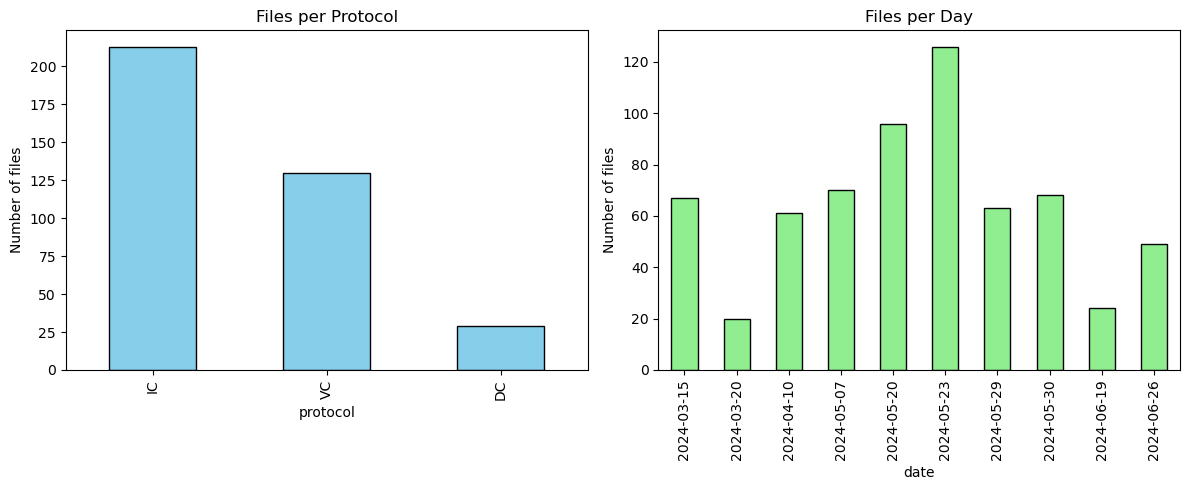

In [22]:
import matplotlib.pyplot as plt

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # adjust figsize as needed

# Files per protocol
protocol_counts = df['protocol'].value_counts()
protocol_counts.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black',
    ax=axes[0],
    title='Files per Protocol'
)
axes[0].set_ylabel('Number of files')

# Files per day
day_counts = df['date'].value_counts().sort_index()
day_counts.plot(
    kind='bar',
    color='lightgreen',
    edgecolor='black',
    ax=axes[1],
    title='Files per Day'
)
axes[1].set_ylabel('Number of files')

plt.tight_layout()
plt.show()


## Filtering

### All dead cells experiments

In [23]:
# Filter rows where comments contain 'dead' (case-insensitive)
dead_cells = df[df['comments'].str.contains('dead', case=False, na=False)]

# Display the result
dead_cells

,exp_nb,cell_id,date,protocol,prot-opt,tp,comments,file_path,file_name
66,67,C2,2024-03-15,IC,ramp,38.0,dead,03.15/C2/2024_03_15_0066 IC ramp 38 dead.abf,2024_03_15_0066 IC ramp 38 dead.abf
627,643,C26,2024-06-26,DC,NaN,25.0,dead,06.26/C2/2024_06_26_0032 25 DC dead.abf,2024_06_26_0032 25 DC dead.abf


### All experiment of the day '2024-05-29'

In [24]:
# Filter rows for a specific day
day_data = df[df['date'] == '2024-05-29']

# Display the result
day_data

,exp_nb,cell_id,date,protocol,prot-opt,tp,comments,file_path,file_name
440,449,C18,2024-05-29,IC,ramp,25.0,NaN,05.29/C1/05.29 C1 IC ramp 25.atf,05.29 C1 IC ramp 25.atf
441,450,C18,2024-05-29,IC,ramp,28.0,NaN,05.29/C1/05.29 C1 IC ramp 28.atf,05.29 C1 IC ramp 28.atf
442,451,C18,2024-05-29,IC,ramp,31.0,NaN,05.29/C1/05.29 C1 IC ramp 31.atf,05.29 C1 IC ramp 31.atf
443,452,C18,2024-05-29,IC,ramp,34.0,NaN,05.29/C1/05.29 C1 IC ramp 34.atf,05.29 C1 IC ramp 34.atf
444,453,C18,2024-05-29,IC,ramp,37.0,NaN,05.29/C1/05.29 C1 IC ramp 37.atf,05.29 C1 IC ramp 37.atf
...,...,...,...,...,...,...,...,...,...
498,507,C19,2024-05-29,NaN,NaN,32.0,NaN,05.29/C2/2024_05_29_0032.abf,2024_05_29_0032.abf
499,508,C20,2024-05-29,NaN,NaN,33.0,immature,05.29/C3 immature/2024_05_29_0033.abf,2024_05_29_0033.abf
500,509,C20,2024-05-29,NaN,NaN,34.0,immature,05.29/C3 immature/2024_05_29_0034.abf,2024_05_29_0034.abf
501,510,C20,2024-05-29,NaN,NaN,35.0,immature,05.29/C3 immature/2024_05_29_0035.abf,2024_05_29_0035.abf


### All `IC ramp` 

In [25]:
# Filter rows with protocol 'IC' and protocol_option 'ramp'
ic_ramp_cells = df[(df['protocol'] == 'IC') & (df['prot-opt'] == 'ramp')]

# Display the result
ic_ramp_cells

,exp_nb,cell_id,date,protocol,prot-opt,tp,comments,file_path,file_name
1,2,C1,2024-03-15,IC,ramp,23.0,NaN,03.15/C1/2024_03_15_0001 IC ramp 23.abf,2024_03_15_0001 IC ramp 23.abf
4,5,C1,2024-03-15,IC,ramp,25.0,NaN,03.15/C1/2024_03_15_0004 IC ramp 25.abf,2024_03_15_0004 IC ramp 25.abf
7,8,C1,2024-03-15,IC,ramp,27.0,NaN,03.15/C1/2024_03_15_0007 IC ramp 27.abf,2024_03_15_0007 IC ramp 27.abf
10,11,C1,2024-03-15,IC,ramp,29.0,NaN,03.15/C1/2024_03_15_0010 IC ramp 29.abf,2024_03_15_0010 IC ramp 29.abf
13,14,C1,2024-03-15,IC,ramp,31.0,NaN,03.15/C1/2024_03_15_0013 IC ramp 31.abf,2024_03_15_0013 IC ramp 31.abf
...,...,...,...,...,...,...,...,...,...
629,645,C27,2024-06-26,IC,ramp,25.0,NaN,06.26/C3/2024_06_26_0034 IC ramp 25.abf,2024_06_26_0034 IC ramp 25.abf
634,650,C27,2024-06-26,IC,ramp,28.0,NaN,06.26/C3/2024_06_26_0039 IC ramp 28.abf,2024_06_26_0039 IC ramp 28.abf
636,652,C27,2024-06-26,IC,ramp,31.0,NaN,06.26/C3/2024_06_26_0041 IC ramp 31.abf,2024_06_26_0041 IC ramp 31.abf
639,655,C27,2024-06-26,IC,ramp,34.0,NaN,06.26/C3/2024_06_26_0044 IC ramp 34.abf,2024_06_26_0044 IC ramp 34.abf


## `csvkit` the command-line Swiss Army knife
```{index} csvkit
```

OK, notebooks are great, but when navigating through data directories, you may come across a CSV file—or, if you’re less lucky, an Excel file. Don’t panic: there’s a handy tool for that: [csvkit](https://csvkit.readthedocs.io/en/latest/), it is a (nice) suite of command-line tools for converting to and working with CSV, the king of tabular file formats. See the [tutorial](https://csvkit.readthedocs.io/en/latest/tutorial.html).

### Installation under you favorite conda environment

```
conda activate python-dsspikes-env
conda install -c conda-forge csvkit # That updates the live environment.
```
Export the environment back to `environment.yml`: Now that your environment has `csvkit`, you need to reflect it in your YAML file:
```
conda env export --from-history > environment.yml
```
`--from-history` ensures only the packages you explicitly installed are recorded (cleaner file, avoids tons of build hashes).
Now your `environment.yml` will include csvkit in dependencies.





### Basics command-line tools

#### `in2csv`: Excel Slayer
```{index} csvkit; in2csv
```
converts various tabular data formats—like Excel (.xls, .xlsx), DBF, fixed-width, or even Google Sheets—into clean, standard CSV.
```
# Convert Excel to CSV and print to stdout
in2csv data.xlsx

# Convert Excel to CSV and save to a file
in2csv data.xlsx > data.csv

# List sheet names in an Excel file
in2csv -n data.xlsx

# Convert a specific sheet
in2csv -s "Sheet1" data.xlsx > data.csv
```
Convert formats, here CSV to JSON:
```
in2csv data/records_fake_metadata.csv | csvjson > metadata.json
```

#### `csvlook`: Data Periscope
```{index} csvkit; csvlook
```
Quickly inspect your CSV in the terminal. Allows you to display CSV files in a nicely formatted, readable table in the terminal — almost like a “pretty-printed” view of your data.
Pipe to `less -S` to scroll horizontally:
```
csvlook data/records_fake_metadata.csv | less -S
```
Preview the first few rows:
```
csvlook data/records_fake_metadata.csv | head -n 12
```

#### `csvcut`: Data Scalpel
```{index} csvkit; csvcut
```

Select columns by name or index:
```
# By name
csvcut -c cell_id,protocol,prot-opt data/records_fake_metadata.csv

# By index (first column is 1)
csvcut -c 1,4,6 data/records_fake_metadata.csv
```

#### `csvgrep`: Data Filter
```{index} csvkit; csvgrep
```
Filter rows based on column values:
```
# Keep only rows where protocol is IC
csvgrep -c protocol -m IC data/records_fake_metadata.csv

# Keep only rows where prot-opt contains "ramp"
csvgrep -c prot-opt -m ramp data/records_fake_metadata.csv
```

#### `csvsort`: Data Organizer
```{index} csvkit; csvsort
```
Sort your CSV by one or more columns:
```
# Sort by date
csvsort -c date data/records_fake_metadata.csv

# Sort by protocol, then by date
csvsort -c protocol,date data/records_fake_metadata.csv
```

#### `csvstat`: Quick Stats
```{index} csvkit; csvstat
```
Get basic stats and info about the CSV:
```
csvstat data/records_fake_metadata.csv
```

#### Combining commands
You can pipe all the line commands. For example, get cell_id and file_name for all IC steps:
```
csvgrep -c protocol -m IC data/records_fake_metadata.csv \
  | csvgrep -c prot-opt -m steps \
  | csvcut -c cell_id,file_name \
  | csvlook
```

#### Examples

Look at column names:

In [55]:
!csvcut -n  data/records_fake_metadata.csv 

  1: exp_nb
  2: cell_id
  3: date
  4: protocol
  5: prot-opt
  6: tp
  7: comments
  8: file_path
  9: file_name


Pretty print of the (head of) columns 2,3,8:

In [57]:
!csvcut -c 2,3,8 data/records_fake_metadata.csv | csvlook | head

| cell_id |       date | file_path                                       |
| ------- | ---------- | ----------------------------------------------- |
| C1      | 2024-03-15 | 03.15/C1/2024_03_15_0000 IC steps 23.abf        |
| C1      | 2024-03-15 | 03.15/C1/2024_03_15_0001 IC ramp 23.abf         |
| C1      | 2024-03-15 | 03.15/C1/2024_03_15_0002 IC sin 23.abf          |
| C1      | 2024-03-15 | 03.15/C1/2024_03_15_0003 VC ramp 23.abf         |
| C1      | 2024-03-15 | 03.15/C1/2024_03_15_0004 IC ramp 25.abf         |
| C1      | 2024-03-15 | 03.15/C1/2024_03_15_0005 IC sin 25.abf          |
| C1      | 2024-03-15 | 03.15/C1/2024_03_15_0006 VC ramp 25.abf         |
| C1      | 2024-03-15 | 03.15/C1/2024_03_15_0007 IC ramp 27.abf         |


Stats on "date" and "tp:

In [53]:
!csvcut -c date,tp data/records_fake_metadata.csv | csvstat

  1. "date"

	Type of data:          Date
	Contains null values:  False
	Non-null values:       644
	Unique values:         10
	Smallest value:        2024-03-15
	Largest value:         2024-06-26
	Most common values:    2024-05-23 (126x)
	                       2024-05-20 (96x)
	                       2024-05-07 (70x)
	                       2024-05-30 (68x)
	                       2024-03-15 (67x)

  2. "tp"

	Type of data:          Number
	Contains null values:  True (excluded from calculations)
	Non-null values:       635
	Unique values:         73
	Smallest value:        0,
	Largest value:         69,
	Sum:                   18 044,5
	Mean:                  28,417
	Median:                28,
	StDev:                 12,181
	Most decimal places:   1
	Most common values:    25, (96x)
	                       34, (66x)
	                       31, (50x)
	                       28, (45x)
	                       40, (33x)

Row count: 644


Show a nice table of all files where "prot-opt" is steps, including only the "cell_id", "protocol", "prot-opt", and "file_name" columns:

In [34]:
!csvcut -c cell_id,protocol,prot-opt,file_name data/records_fake_metadata.csv | csvgrep -c prot-opt -m steps | csvlook

| cell_id | protocol | prot-opt | file_name                              |
| ------- | -------- | -------- | -------------------------------------- |
| C1      | IC       | steps    | 2024_03_15_0000 IC steps 23.abf        |
| C1      | IC       | steps    | 2024_03_15_0018 IC steps 34.abf        |
| C2      | IC       | steps    | 2024_03_15_0036 IC steps 23.abf        |
| C3      | IC       | steps    | 2024_03_20_0007 IC square steps 38.abf |
| C23     | IC       | steps    | 2024_06_19_0000 IC steps 25.abf        |
| C23     | IC       | steps    | 2024_06_19_0009 IC steps 34.abf        |
| C24     | IC       | steps    | 2024_06_19_0014 IC steps 25.abf        |
| C25     | IC       | steps    | 2024_06_26_0000 IC steps 25.abf        |
| C25     | IC       | steps    | 2024_06_26_0016 IC steps 34.abf        |
| C25     | IC       | steps    | 2024_06_26_0022 IC steps 40.abf        |
| C26     | IC       | steps    | 2024_06_26_0028 IC steps 25.abf        |
| C27     | IC       | st

You can pipe all the line commands. For example, get cell_id and file_name for all IC steps:

In [58]:
!bash -c "csvgrep -c protocol -m IC data/records_fake_metadata.csv \
| csvgrep -c prot-opt -m steps \
| csvcut -c cell_id,file_name \
| csvlook"

| cell_id | file_name                              |
| ------- | -------------------------------------- |
| C1      | 2024_03_15_0000 IC steps 23.abf        |
| C1      | 2024_03_15_0018 IC steps 34.abf        |
| C2      | 2024_03_15_0036 IC steps 23.abf        |
| C3      | 2024_03_20_0007 IC square steps 38.abf |
| C23     | 2024_06_19_0000 IC steps 25.abf        |
| C23     | 2024_06_19_0009 IC steps 34.abf        |
| C24     | 2024_06_19_0014 IC steps 25.abf        |
| C25     | 2024_06_26_0000 IC steps 25.abf        |
| C25     | 2024_06_26_0016 IC steps 34.abf        |
| C25     | 2024_06_26_0022 IC steps 40.abf        |
| C26     | 2024_06_26_0028 IC steps 25.abf        |
| C27     | 2024_06_26_0033 IC steps 25.abf        |
| C27     | 2024_06_26_0043 IC steps 34.abf        |


(`bash -c` is a way to tell Bash to execute a command string as if you typed it directly in a terminal)